# Clase 05 — Regresión Logística y KNN
## Naranja X — Modelo de aprobación de crédito personal

---

### Pregunta de negocio
¿A qué solicitantes debería aprobarles un crédito Naranja X para minimizar el riesgo de incumplimiento?

### Hipótesis
Los clientes con mejor score crediticio y menor deuda actual tienen menor probabilidad de incumplir. Un modelo entrenado con historial propio puede cuantificar ese riesgo y reemplazar la evaluación manual.

### Datos disponibles
- **`score_veraz`** — calidad crediticia según buró (escala 1–999)
- **`deuda_actual`** — deuda vigente en otras entidades (ARS)
- **`incumplimiento`** — target: 1 = no pagó / 0 = pagó

---
*CRISP-DM: Business Understanding → Data Understanding → Preparation → Modeling → Evaluation*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix

sns.set_style('whitegrid')

# Azul = pagó / Rojo = incumplió — colores consistentes en todo el notebook
AZUL, ROJO = '#1565C0', '#C62828'

print('Librerías cargadas ✓')

Librerías cargadas ✓


In [2]:
# Funciones auxiliares de visualización — no es necesario leer este código

def frontera_rl(ax, modelo, X_df, y_s, umbral=0.5, titulo=''):
    xx, yy = np.meshgrid(
        np.linspace(X_df.iloc[:, 0].min() * 0.9, X_df.iloc[:, 0].max() * 1.05, 250),
        np.linspace(X_df.iloc[:, 1].min() * 0.9, X_df.iloc[:, 1].max() * 1.05, 250)
    )
    probs = modelo.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, probs >= umbral, alpha=0.18, cmap='RdBu_r', levels=[-0.5, 0.5, 1.5])
    ax.contour(xx, yy, probs, levels=[umbral], colors='black', linewidths=1.8)
    for c, color in {0: AZUL, 1: ROJO}.items():
        mask = y_s == c
        ax.scatter(X_df[mask].iloc[:, 0], X_df[mask].iloc[:, 1],
                   c=color, alpha=0.5, s=14, edgecolors='none')
    ax.set_xlabel(X_df.columns[0], fontsize=8)
    ax.set_ylabel(X_df.columns[1], fontsize=8)
    ax.set_title(titulo, fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}k'))


def frontera_knn(ax, modelo, X_df, y_s, titulo='', scaler=None):
    xx, yy = np.meshgrid(
        np.linspace(X_df.iloc[:, 0].min() * 0.9, X_df.iloc[:, 0].max() * 1.05, 200),
        np.linspace(X_df.iloc[:, 1].min() * 0.9, X_df.iloc[:, 1].max() * 1.05, 200)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    if scaler is not None:
        grid = scaler.transform(grid)
    pred = modelo.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, pred, alpha=0.18, cmap='RdBu_r', levels=[-0.5, 0.5, 1.5])
    for c, color in {0: AZUL, 1: ROJO}.items():
        mask = y_s == c
        ax.scatter(X_df[mask].iloc[:, 0], X_df[mask].iloc[:, 1],
                   c=color, alpha=0.5, s=14, edgecolors='none')
    ax.set_xlabel(X_df.columns[0], fontsize=8)
    ax.set_ylabel(X_df.columns[1], fontsize=8)
    ax.set_title(titulo, fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}k'))


print('Funciones de visualización cargadas ✓')

Funciones de visualización cargadas ✓


---
## 2. Data Understanding

In [3]:
# Step 1: Cargar el dataset completo
df = pd.read_csv('solicitudes_naranjax.csv')

print(f'Dataset: {len(df)} solicitudes | {df.shape[1]-1} variables + target')
print(f'Incumplieron: {df.incumplimiento.sum()} ({df.incumplimiento.mean():.1%})')
print(f'Pagaron:      {(df.incumplimiento==0).sum()} ({(df.incumplimiento==0).mean():.1%})')
print()
df.head()

Dataset: 800 solicitudes | 7 variables + target
Incumplieron: 332 (41.5%)
Pagaron:      468 (58.5%)



,ingreso_mensual,score_veraz,edad,antiguedad_laboral,deuda_actual,relacion_laboral,productos_naranja,incumplimiento
0,968000,453,26,9.4,304000,0,0,0
1,1800000,425,58,9.5,150000,2,0,0
2,689000,466,64,10.8,606000,2,1,0
3,280000,313,22,2.0,591000,2,1,1
4,869000,434,25,5.5,551000,0,1,0


In [4]:
# Step 2: EDA — ¿qué variables discriminan mejor entre quién paga y quién no?
#
# Si la diferencia entre grupos es grande → esa variable tiene más poder predictivo
#
cols = ['ingreso_mensual', 'score_veraz', 'edad', 'antiguedad_laboral',
        'deuda_actual', 'productos_naranja']

print('Mediana por grupo (0 = Pagó / 1 = Incumplió):')
print(df.groupby('incumplimiento')[cols].median().round(0).T
      .rename(columns={0: 'Pagó', 1: 'Incumplió'}).to_string())

Mediana por grupo (0 = Pagó / 1 = Incumplió):
incumplimiento          Pagó  Incumplió
ingreso_mensual     730000.0   563500.0
score_veraz            449.0      354.0
edad                    49.0       41.0
antiguedad_laboral       7.0        6.0
deuda_actual        258500.0   391500.0
productos_naranja        1.0        0.0


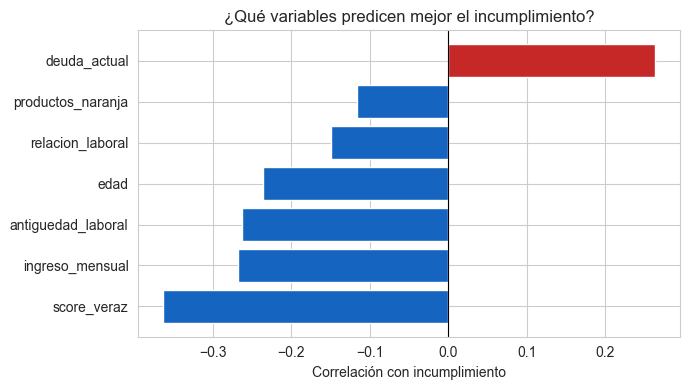

score_veraz  → -0.36  (mejor score = menos riesgo)
deuda_actual → 0.26  (más deuda = más riesgo)

→ Usamos estas dos para modelar y visualizar la frontera de decisión.
→ El ingreso solo no explica el riesgo — la deuda acumulada importa más.


In [5]:
# Step 3: Correlación con el target — ranking de poder predictivo
#
# Barra AZUL  → más de esta variable = menos riesgo de incumplir
# Barra ROJA  → más de esta variable = más riesgo de incumplir
# Barras más largas = variables más discriminantes
#
corr = df.corr(numeric_only=True)['incumplimiento'].drop('incumplimiento').sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(corr.index, corr.values,
        color=[ROJO if v > 0 else AZUL for v in corr.values],
        edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Correlación con incumplimiento')
ax.set_title('¿Qué variables predicen mejor el incumplimiento?')
plt.tight_layout()
plt.show()

print(f'score_veraz  → {corr["score_veraz"]:.2f}  (mejor score = menos riesgo)')
print(f'deuda_actual → {corr["deuda_actual"]:.2f}  (más deuda = más riesgo)')
print()
print('→ Usamos estas dos para modelar y visualizar la frontera de decisión.')
print('→ El ingreso solo no explica el riesgo — la deuda acumulada importa más.')

X = df[['score_veraz', 'deuda_actual']]
y = df['incumplimiento']

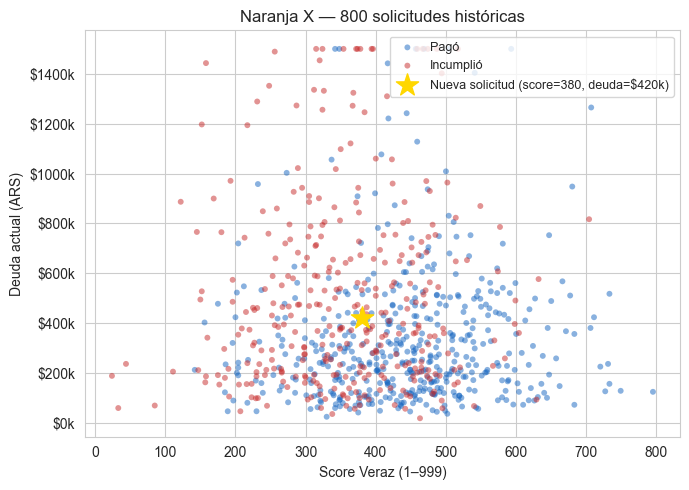

In [6]:
# Step 4: Scatter — ¿los grupos son separables visualmente?
#
# Azul  = pagó     Rojo = incumplió     ★ = solicitud de la pregunta de negocio
#
fig, ax = plt.subplots(figsize=(7, 5))
for c, label in {0: 'Pagó', 1: 'Incumplió'}.items():
    mask = y == c
    ax.scatter(X[mask]['score_veraz'], X[mask]['deuda_actual'],
               c=AZUL if c == 0 else ROJO, label=label, alpha=0.5, s=18, edgecolors='none')
ax.scatter(380, 420000, color='gold', s=280, zorder=6, marker='*',
           label='Nueva solicitud (score=380, deuda=$420k)')
ax.set_xlabel('Score Veraz (1–999)')
ax.set_ylabel('Deuda actual (ARS)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}k'))
ax.set_title('Naranja X — 800 solicitudes históricas')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Los grupos se SOLAPAN → ningún modelo va a acertar siempre
# Eso es realista: el riesgo crediticio no es perfectamente predecible

---
## 3. Data Preparation

In [7]:
# Step 5: Train/Test Split + StandardScaler
#
# TRAIN (70%) → el modelo aprende
# TEST  (30%) → evaluamos con datos que el modelo NUNCA vio
#
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
print(f'Train: {len(X_train)} solicitudes | Test: {len(X_test)} solicitudes')

# StandardScaler: transforma a media=0, desvío=1
# fit solo sobre train → transform sobre train y test con la misma escala
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Train: 560 solicitudes | Test: 240 solicitudes


---
## 4. Modeling

### 4a. Regresión Logística

Modelo **paramétrico**: aprende coeficientes fijos (β) que determinan el peso de cada variable. La frontera de decisión es **siempre una línea recta**.  

No predice pagó/no pagó directamente: usa la **función sigmoide** para convertir cualquier número en una probabilidad entre 0 y 1. El **umbral** convierte esa probabilidad en una decisión de negocio.

/var/folders/nz/2nwf40qd06951mskmhzlp3t00000gq/T/ipykernel_22439/2105725536.py:26: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/nz/2nwf40qd06951mskmhzlp3t00000gq/T/ipykernel_22439/2105725536.py:26: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/nz/2nwf40qd06951mskmhzlp3t00000gq/T/ipykernel_22439/2105725536.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: G

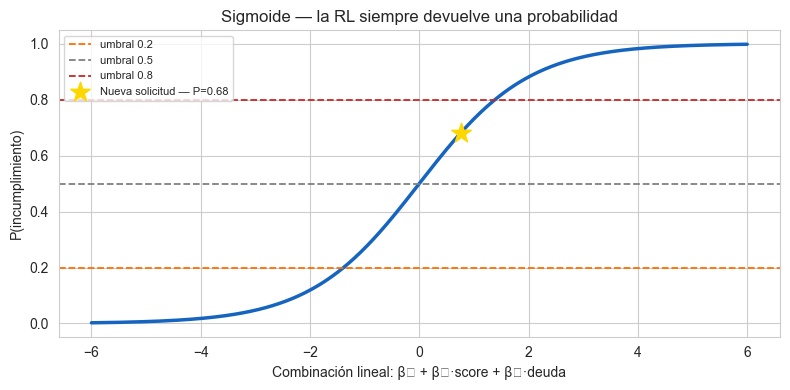

In [8]:
# Step 6: Función sigmoide
#
# Línea azul     → probabilidad de incumplimiento para cada valor de z
# Líneas punteadas → tres umbrales posibles
# Estrella dorada → dónde cae nuestra solicitud: P(incumplir) = 0.68
#
#   Con umbral 0.5 → RECHAZADA (0.68 > 0.5)
#   Con umbral 0.8 → APROBADA  (0.68 < 0.8)
#   El modelo no cambió — el criterio de negocio sí
#
z = np.linspace(-6, 6, 400)
sigma = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(z, sigma, AZUL, lw=2.5)
for u, col, lbl in [(0.2, '#FF6F00', 'umbral 0.2'),
                     (0.5, 'grey',    'umbral 0.5'),
                     (0.8, ROJO,      'umbral 0.8')]:
    ax.axhline(u, color=col, ls='--', lw=1.3, label=lbl)
ax.scatter(np.log(0.68 / 0.32), 0.68, color='gold', s=220,
           zorder=6, marker='*', label='Nueva solicitud — P=0.68')
ax.set_xlabel('Combinación lineal: β₀ + β₁·score + β₂·deuda')
ax.set_ylabel('P(incumplimiento)')
ax.set_title('Sigmoide — la RL siempre devuelve una probabilidad')
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


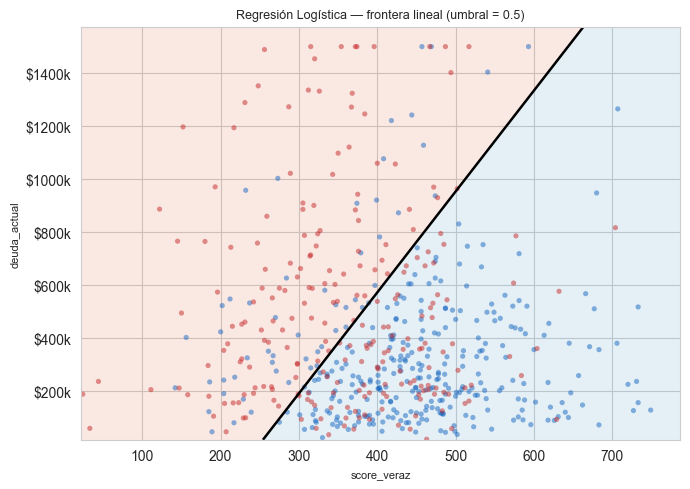

Accuracy:  67.9%  → de cada 10 solicitudes, clasifica bien ~7
Precision: 62.9%  → de las que rechaza, acierta este %


In [9]:
# Step 7: Entrenar y visualizar la frontera
#
# Zona AZUL  → el modelo predice que pagará  → aprobamos
# Zona ROJA  → el modelo predice incumplimiento → rechazamos
# Línea negra → el umbral de decisión (0.5)
#
# La frontera es siempre una LÍNEA RECTA → limitación de la RL
#
rl = LogisticRegression(max_iter=1000, random_state=42)
rl.fit(X_train, y_train)
y_pred_rl  = rl.predict(X_test)
y_proba_rl = rl.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(7, 5))
frontera_rl(ax, rl, X_train, y_train, umbral=0.5,
            titulo='Regresión Logística — frontera lineal (umbral = 0.5)')
plt.tight_layout()
plt.show()

acc  = accuracy_score(y_test, y_pred_rl)
prec = precision_score(y_test, y_pred_rl, zero_division=0)
print(f'Accuracy:  {acc:.1%}  → de cada 10 solicitudes, clasifica bien ~{round(acc*10)}')
print(f'Precision: {prec:.1%}  → de las que rechaza, acierta este %')

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


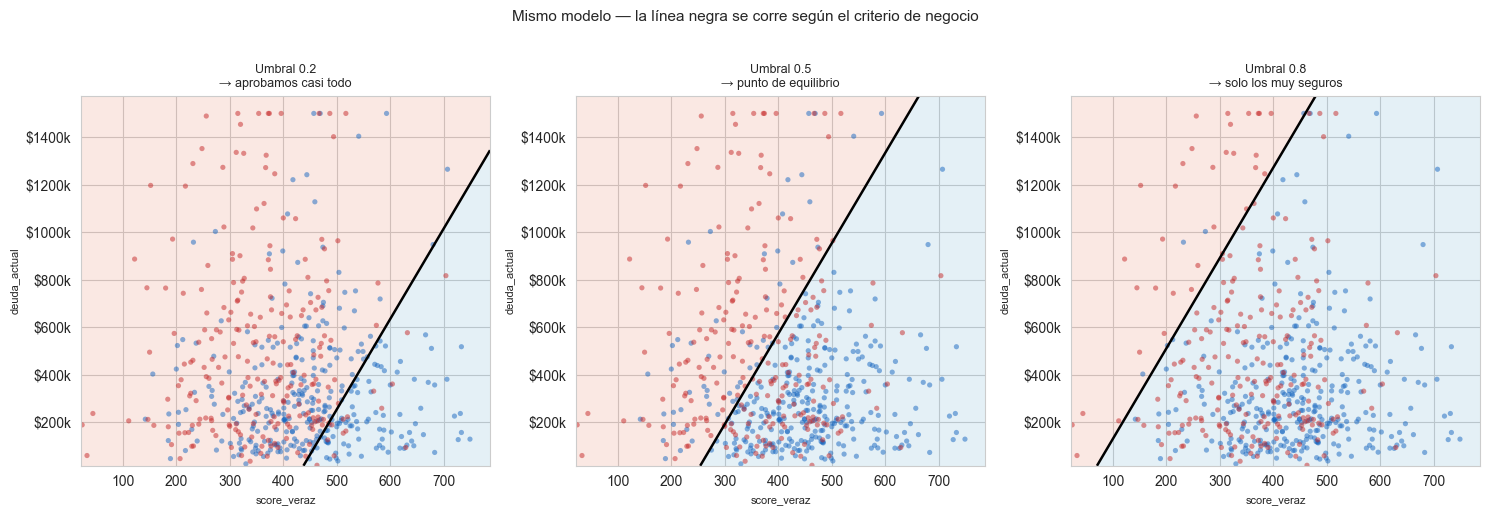

In [10]:
# Step 8: Jugar con los umbrales — el momento central
#
# Los tres gráficos muestran el MISMO modelo. Solo cambia la línea de corte.
#
# Umbral 0.2 → zona azul grande → aprobamos casi todo
#              más defaults aprobados, menos buenos rechazados
#
# Umbral 0.8 → zona azul chica → solo aprobamos los muy seguros
#              menos defaults aprobados, más buenos rechazados
#
# No hay respuesta correcta — depende del negocio
#
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, u, t in zip(axes,
    [0.2, 0.5, 0.8],
    ['Umbral 0.2\n→ aprobamos casi todo',
     'Umbral 0.5\n→ punto de equilibrio',
     'Umbral 0.8\n→ solo los muy seguros']):
    frontera_rl(ax, rl, X_train, y_train, umbral=u, titulo=t)
plt.suptitle('Mismo modelo — la línea negra se corre según el criterio de negocio',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# Step 9: ¿Cuánto le cuesta a Naranja X cada criterio de aprobación?
#
# FALSO POSITIVO: aprobamos → incumplió → perdemos capital  (~$162.500)
# FALSO NEGATIVO: rechazamos → hubiera pagado → margen perdido (~$45.000)
#
COSTO_FP = 162_500
COSTO_FN =  45_000

resultados = []
for u in [0.2, 0.5, 0.8]:
    pred = (y_proba_rl >= u).astype(int)
    fp   = ((pred == 0) & (y_test == 1)).sum()
    fn   = ((pred == 1) & (y_test == 0)).sum()
    resultados.append({
        'Umbral':             u,
        'Aprobadas':          int((pred == 0).sum()),
        'Defaults aprobados': int(fp),
        'Buenos rechazados':  int(fn),
        'Costo total ($)':    f'${fp * COSTO_FP + fn * COSTO_FN:,.0f}'
    })

print('Impacto económico de cada umbral (sobre 240 solicitudes del test set):')
print()
pd.DataFrame(resultados)

Impacto económico de cada umbral (sobre 240 solicitudes del test set):



,Umbral,Aprobadas,Defaults aprobados,Buenos rechazados,Costo total ($)
0,0.2,46,6,100,"$5,475,000"
1,0.5,151,44,33,"$8,635,000"
2,0.8,223,89,6,"$14,732,500"


---
### 4b. KNN — K-Nearest Neighbors

Modelo **no paramétrico**: no aprende coeficientes. No asume ninguna forma. Clasifica comparando cada solicitud nueva con todas las históricas y eligiendo la clase mayoritaria entre los K más cercanos.

> *"No voy a imponer una fórmula. Voy a dejar que los datos definan la forma."*

**Distancias:**  
- **Euclidiana** — línea recta entre dos puntos  
- **Manhattan** — suma de diferencias absolutas (como caminar en cuadrícula)

Ambas son sensibles a la escala → el escalado es obligatorio.

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/var/folders/nz/2nwf40qd06951mskmhzlp3t00000gq/T/ipykernel_22439/1466945246.py:26: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/nz/2nwf40qd06951mskmhzlp3t00000gq/T/ipykernel_22439/1466945246.py:26: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


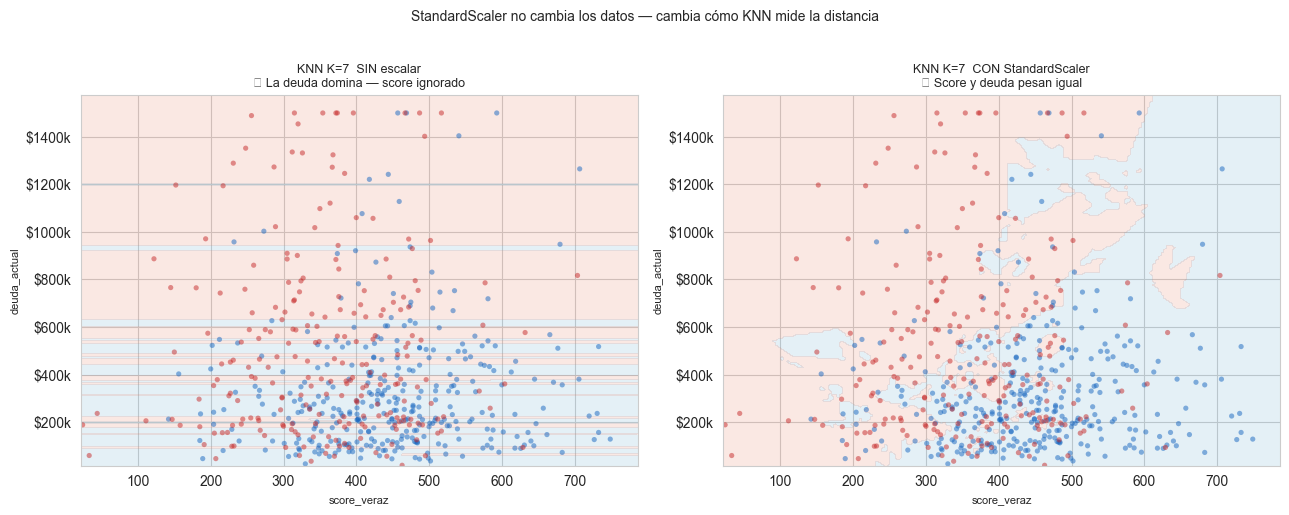

In [12]:
# Step 10: El problema del escalado en KNN
#
# Score Veraz:  rango  1 – 999
# Deuda actual: rango  $0 – $1.500.000
#
# Sin escalar: $100.000 de diferencia en deuda pesa 100x más
# que 100 puntos de diferencia en score → el score queda ignorado
#
# Imagen izquierda → frontera casi horizontal (la deuda lo domina todo)
# Imagen derecha   → frontera diagonal (score y deuda contribuyen igual)
#
knn_sin = KNeighborsClassifier(n_neighbors=7)
knn_sin.fit(X_train.values, y_train)

knn_con = KNeighborsClassifier(n_neighbors=7)
knn_con.fit(X_train_sc, y_train)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
frontera_knn(axes[0], knn_sin, X_train, y_train,
             titulo='KNN K=7  SIN escalar\n⚠ La deuda domina — score ignorado')
frontera_knn(axes[1], knn_con, X_train, y_train,
             titulo='KNN K=7  CON StandardScaler\n✓ Score y deuda pesan igual',
             scaler=scaler)
plt.suptitle('StandardScaler no cambia los datos — cambia cómo KNN mide la distancia',
             fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


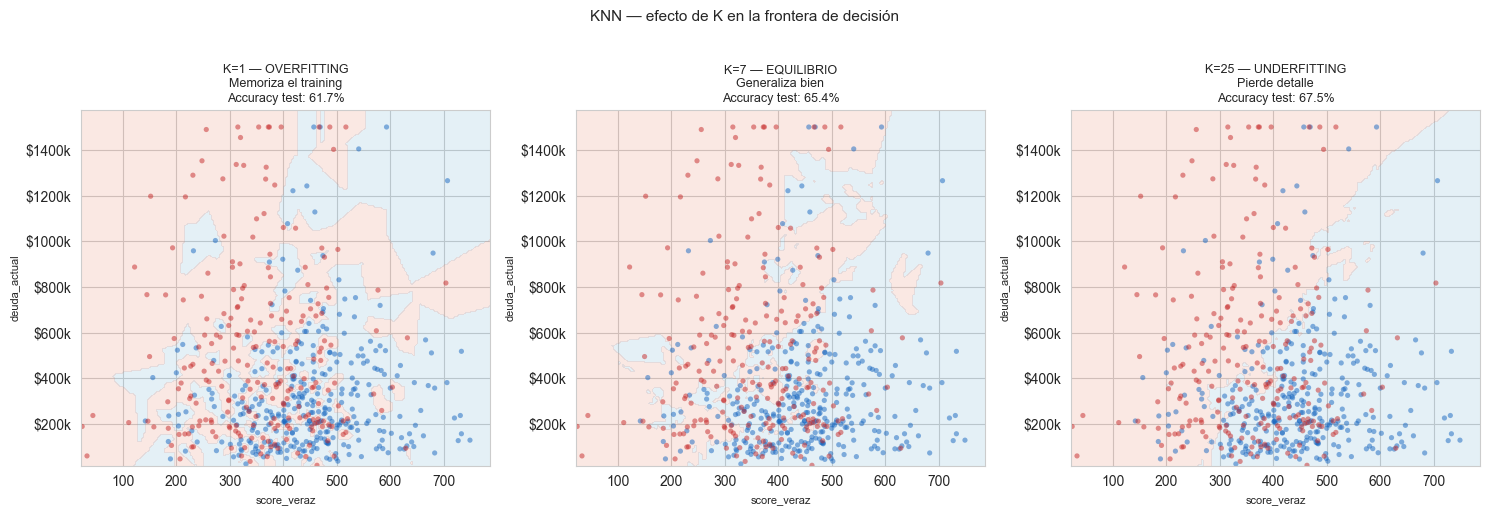

In [13]:
# Step 11: Jugar con K — encontrar el sweet spot
#
# K=1  → memoriza cada solicitud del training → OVERFITTING
#         Frontera muy irregular, falla en datos nuevos
#
# K=7  → 7 vecinos → frontera más suave → EQUILIBRIO
#
# K=25 → promedia demasiados vecinos → pierde detalle → UNDERFITTING
#
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, k, titulo in zip(axes,
    [1, 7, 25],
    ['K=1 — OVERFITTING\nMemoriza el training',
     'K=7 — EQUILIBRIO\nGeneraliza bien',
     'K=25 — UNDERFITTING\nPierde detalle']):
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_sc, y_train)
    acc = accuracy_score(y_test, knn_k.predict(X_test_sc))
    frontera_knn(ax, knn_k, X_train, y_train,
                 titulo=f'{titulo}\nAccuracy test: {acc:.1%}', scaler=scaler)
plt.suptitle('KNN — efecto de K en la frontera de decisión', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Evaluation

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


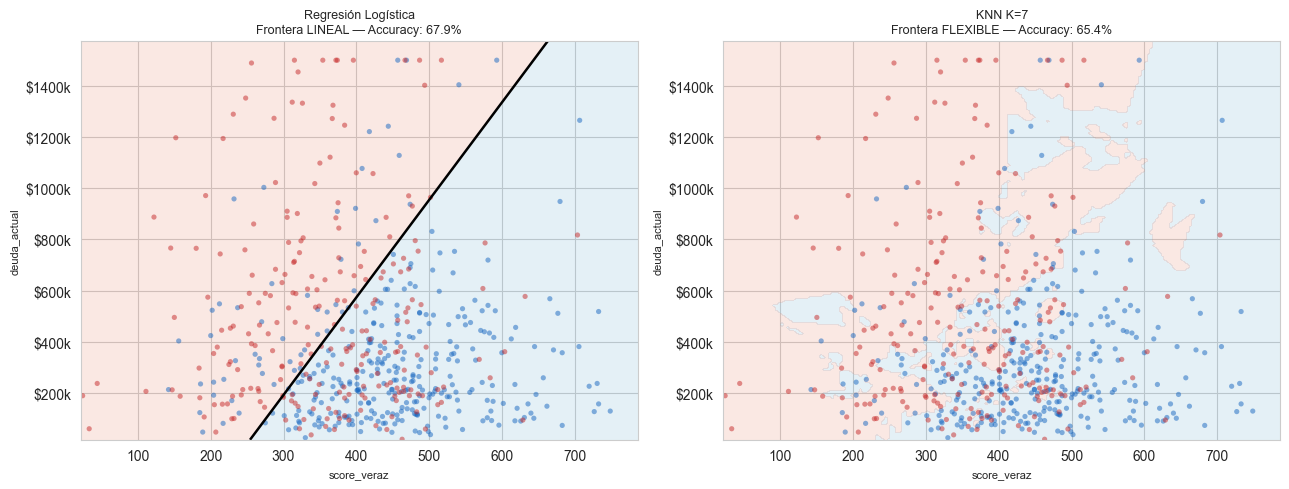

Métrica          Reg. Logística    KNN K=7
------------------------------------------
Accuracy                 67.9%     65.4%
Precision                62.9%     59.6%

Performance similar → la diferencia decisiva es la INTERPRETABILIDAD.

RL:  "Su score 380 y deuda $420k dan P(incumplir)=68%, sobre el umbral vigente."
KNN: "Se parecía a solicitudes que incumplieron." → no alcanza ante el BCRA.


In [14]:
# Step 12: RL vs KNN — comparación final
#
# ACCURACY:  % de solicitudes clasificadas correctamente en total
# PRECISION: de las que RECHAZA, ¿qué % efectivamente hubiera incumplido?
#            → Alta precision = cuando rechazamos, tenemos razón
#
knn7 = KNeighborsClassifier(n_neighbors=7)
knn7.fit(X_train_sc, y_train)
y_pred_knn = knn7.predict(X_test_sc)

acc_rl  = accuracy_score(y_test, y_pred_rl)
acc_knn = accuracy_score(y_test, y_pred_knn)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
frontera_rl(axes[0], rl, X_train, y_train, umbral=0.5,
            titulo=f'Regresión Logística\nFrontera LINEAL — Accuracy: {acc_rl:.1%}')
frontera_knn(axes[1], knn7, X_train, y_train,
             titulo=f'KNN K=7\nFrontera FLEXIBLE — Accuracy: {acc_knn:.1%}',
             scaler=scaler)
plt.tight_layout()
plt.show()

prec_rl  = precision_score(y_test, y_pred_rl,  zero_division=0)
prec_knn = precision_score(y_test, y_pred_knn, zero_division=0)

print(f'{"Métrica":<12} {"Reg. Logística":>18} {"KNN K=7":>10}')
print('-' * 42)
print(f'{"Accuracy":<12} {acc_rl:>17.1%} {acc_knn:>9.1%}')
print(f'{"Precision":<12} {prec_rl:>17.1%} {prec_knn:>9.1%}')
print()
print('Performance similar → la diferencia decisiva es la INTERPRETABILIDAD.')
print()
print('RL:  "Su score 380 y deuda $420k dan P(incumplir)=68%, sobre el umbral vigente."')
print('KNN: "Se parecía a solicitudes que incumplieron." → no alcanza ante el BCRA.')

---
## Conclusión

### La hipótesis se confirma
Los clientes con mejor score Veraz y menor deuda actual incumplen menos. El EDA lo mostró, el scatter lo confirmó visualmente, y ambos modelos lo capturan.

### Modelo recomendado: Regresión Logística
Performance equivalente a KNN, pero **interpretable**: Naranja X puede justificar cada decisión ante el BCRA y ante el cliente.

### El umbral lo decide el negocio, no el algoritmo
- **Recesión / incobrabilidad alta** → subir el umbral → proteger el capital
- **Expansión / crecer la cartera** → bajar el umbral → aprobar más

### Respuesta a la pregunta de negocio
Aprobar a los solicitantes con probabilidad de incumplimiento **por debajo del umbral** que el equipo de riesgo defina según el contexto. Con los costos actuales, el umbral óptimo surge de la tabla de la celda 9.

---
## Para ver en casa

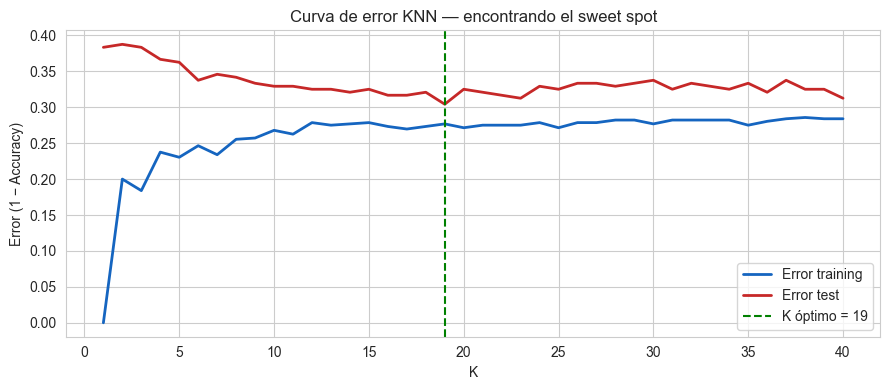

K óptimo para este dataset: 19


In [15]:
# Para ver en casa — Curva de error KNN
#
# K=1:      error training=0% (memoriza todo) → overfitting
# K óptimo: mínimo error de test → sweet spot
# K grande: ambos errores suben → underfitting
#
ks = range(1, 41)
err_train, err_test = [], []
for k in ks:
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train_sc, y_train)
    err_train.append(1 - accuracy_score(y_train, m.predict(X_train_sc)))
    err_test.append( 1 - accuracy_score(y_test,  m.predict(X_test_sc)))

k_opt = list(ks)[np.argmin(err_test)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ks, err_train, label='Error training', color=AZUL, lw=2)
ax.plot(ks, err_test,  label='Error test',     color=ROJO,  lw=2)
ax.axvline(k_opt, color='green', ls='--', lw=1.5, label=f'K óptimo = {k_opt}')
ax.set_xlabel('K')
ax.set_ylabel('Error (1 − Accuracy)')
ax.set_title('Curva de error KNN — encontrando el sweet spot')
ax.legend()
plt.tight_layout()
plt.show()

print(f'K óptimo para este dataset: {k_opt}')

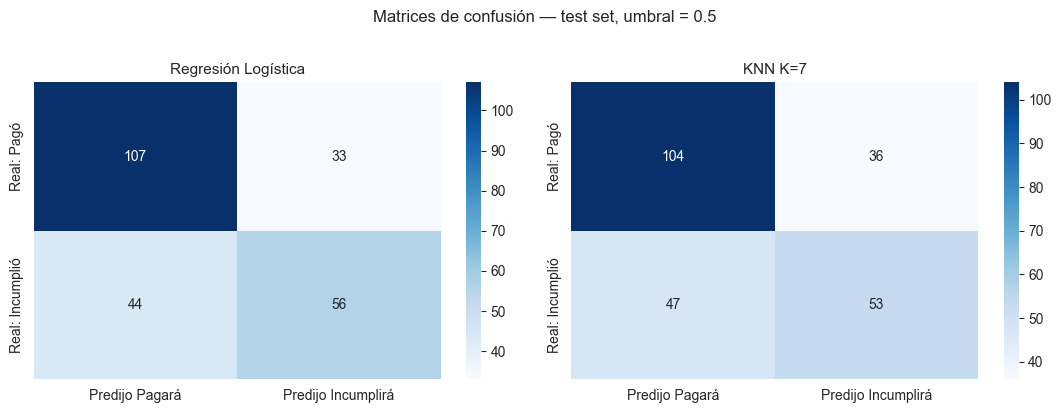

¿Cuál modelo comete más Falsos Positivos?
¿Cambia esa respuesta con el umbral óptimo de la tabla de costos?


In [16]:
# Para ver en casa — Matrices de confusión
#
#                   Predijo Pagará    Predijo Incumplirá
#   Real: Pagó   →  Verdadero Neg.    Falso Positivo ← caro
#   Real: Incumplió→ Falso Negativo   Verdadero Pos.
#
# FP = aprobamos → incumplió → pérdida de capital
# FN = rechazamos → hubiera pagado → margen perdido
#
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, y_pred, titulo in zip(axes,
    [y_pred_rl, y_pred_knn], ['Regresión Logística', 'KNN K=7']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Predijo Pagará', 'Predijo Incumplirá'],
                yticklabels=['Real: Pagó', 'Real: Incumplió'])
    ax.set_title(titulo, fontsize=11)
plt.suptitle('Matrices de confusión — test set, umbral = 0.5', y=1.02)
plt.tight_layout()
plt.show()

print('¿Cuál modelo comete más Falsos Positivos?')
print('¿Cambia esa respuesta con el umbral óptimo de la tabla de costos?')